# Read in data

In [2]:
import pandas as pd
import numpy as np
from itertools import product, combinations
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from pingouin import ttest
from pylatexenc.latexencode import unicode_to_latex as text2latex
from scipy import stats
from statsmodels.regression.mixed_linear_model import MixedLM
from scipy.stats import bootstrap

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.helpers import make_aesthetic, cat_stats
from src.statsmodels_handler import StatsmodelsHandler, clean_var_name_from_formula
import random

random.seed(42)
np.random.seed(42)

mypal = make_aesthetic()

mypal =  [
            "#A9A9A9",  # Light gray
            "#D41876",  # Magenta-pink
            "#020887",  # Dark blue
            "#89DAFF",  # Light blue
            "#F18805",  # Orange
            "#826AED",  # Purple-blue
            "#342E37",  # Dark purple-gray

            "#D4B2D8",  # Light purple
            "#00A896",  # Teal-green
            "#7DCD85",  # Light green
            "#E3B505",  # Yellow
            "#F7B2AD",  # Light pink/salmon

            "#F45B69",  # Coral-red
            "#E87461",  # Orange-red
            "#7E6551"  # Brown
        ]


def make_bold(x):
	"""
	This function is used to make part of the title bold like as a subtitle.
	Basically, it's using latex to render a (sub)string bold in matplot.
	But make_aesthetic() should handle using Arial for math font,
	so it won't look weird.
	>>> full_title = f"{make_bold("Regression Coefficients of Estimated Prevalence From Multiverse")}\n(Baseline is raw data with no weighting and no dropping)"

	"""
	#
	words = x.split()
	words = ' \\ '.join([w for w in words])  # Escape backslash properly
	bold_str = f"$\\bf{{{words}}}$"  # Correctly format the f-string
	return bold_str

def did_use(x):
    if "never" in x.lower():
        return 0
    else:
        return 1

def short_domain(x):
    if "convention" in x.lower():
        return "conventional"
    elif "moral" in x.lower():
        return "moral"
    elif "personal" in x.lower():
        return "personal"
    else:
        return "other"


def make_df():
    df = pd.read_csv("../data/qualtrics_experiments/desc_norms_interface [typing]_August 23, 2025_20.20.csv")
    # print(sorted(df.columns))
    df = df.iloc[2:]
    df = df.query("DistributionChannel=='anonymous'") # this will remove reponses from using preview link

    data_pts = []
    for i, row in df.iterrows():
        # non_loop_merge_vars
        base_pt = {
            "pid": row['ResponseId'],
            "progress": row['Progress'],
            "duration": float(row['Duration (in seconds)'])/60,
            "finished": row['Finished'],
            "feedback": row['feedback'],
            "llm_usage": row['dv_llm_usage'],
            "usage_convention": row['dv_usage_convention'],
            "usage_moral": row['dv_usage_moral'],
            "usage_personal": row['dv_usage_personal'],
            "llm_usage_binary": did_use(row['dv_llm_usage']),
            "usage_convention_binary": did_use(row['dv_usage_convention']),
            "usage_moral_binary": did_use(row['dv_usage_moral']),
            "usage_personal_binary": did_use(row['dv_usage_personal']),
        }

        # loop and merge columns:
        for i in range(1, 60):
            pre = float(row.get(f'{i}_lm_pre_11'))
            post =float( row.get(f'{i}_lm_post_11'))
            qual = row.get(f'{i}_lm_qual')
            if pd.notnull(pre) and pd.notnull(post):
                data_pt = base_pt.copy()
                data_pt['idx'] = i
                data_pt['pre'] = pre
                data_pt['post'] = post
                data_pt['qual'] = qual
                data_pts.append(data_pt)


    # We get a long dataframe with one row per trial per person
    df = pd.DataFrame(data_pts)


    # Merge in metadata
    #############################################
    #############################################
    meta_df = pd.read_csv("../data/clean/ai_rot_stimuli_new_prompt.csv")
    df = df.merge(meta_df, on='idx', how='left')
    #############################################
    #############################################

    # Clean and process
    #############################################
    #############################################

    # Distance stuff
    df['pre_distance'] = np.abs(df['pre'] - df['rating'])
    df['post_distance'] = np.abs(df['post'] - df['rating'])
    df['change_distance'] = df['pre_distance'] - df['post_distance']
    df['did_change_distance'] = df['change_distance'].apply(lambda x: 1 if x > 0 else 0)
    df['did_change'] = 1 * ((df['pre_distance'] - df['post_distance']) != 0)
    df['raw_update'] = df['post'] - df['pre']
    df['raw_ai_distance'] = df['rating'] - df['pre']

    # Domain cleaning
    df['domain'] = df['domain'].map(short_domain)

    # Duration bucketing
    durations = df.drop_duplicates(subset=['pid'])['duration'].to_list()
    mean_duration = np.mean(durations)
    sd_duration = np.std(durations)
    low_threshold = mean_duration - 2*sd_duration
    df['low_duration'] = (df['duration'] < low_threshold)
    print("Number of low duration people")
    print(df['low_duration'].value_counts())


    # Usage cleaning
    usage_map = {
       "No - never used": 0,
       "Yes - less often than several times a week": 1,
       "Yes - several times a week": 2,
       "Yes - about once a day": 3,
       "Yes - several times a day": 4,
        "Yes - almost constantly": 5
    }
    for var in ['usage_personal', 'usage_moral', 'usage_convention']:
        df[f"{var}_int"] = df[var].map(usage_map)
    df['usage_sum'] = df[['usage_personal_int', 'usage_moral_int', 'usage_convention_int']].sum(axis=1)

    # convince type
    df['convince_type'] = np.where(df['rating'] < df['pre'], "Denormalize", "Normalize")


    # implied agreement condition
    stim_data = df.groupby("rot")["pre"].std()
    stim_bins = pd.qcut(
        stim_data,
        q=3,
        labels=["low_agreement", "medium_agreement", "high_agreement"],
        duplicates="drop"
    )

    # map back to original df
    df["implied_agreement_condition"] = df["rot"].map(stim_bins)

    df.to_csv("../data/qualtrics_experiments/desc_norms_init_norm_pilot_long.csv", index=False)

    return df
    #############################################
    #############################################

df = make_df()

Number of low duration people
low_duration
False    226
Name: count, dtype: int64


# Basic data quality checks

Durations
M = 20.94, SD = 10.88, Mdn = 18.08
Mode = 14.42
95% CI [17.18, 26.66]


<Axes: xlabel='duration', ylabel='change_distance'>

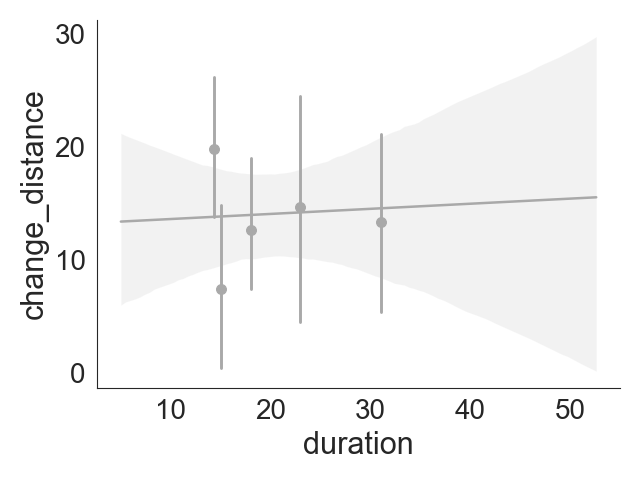

In [3]:
from src.helpers import array_stats
from scipy.stats import ttest_ind, mannwhitneyu

print("Durations")
durations =  array_stats(df.drop_duplicates(subset=['pid'])['duration'].values, include_ci=True)
sns.regplot(data=df, x='duration', y='change_distance', x_bins=5, color='#A9A9A9')



In [4]:
mypal[0]

'#A9A9A9'

 # Descriptives of change

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from src.helpers import array_stats

mypal = make_aesthetic(font_scale=1.2)
effect_size = df['pre_distance'] - df['post_distance']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#################################################################
# Pre_distance and post_distance as overlaid histograms
#################################################################
ax1 = axes[0]
ax1.hist(df['pre_distance'], bins=30, alpha=1, label='Pre Exposure Distance',  edgecolor='black')
ax1.hist(df['post_distance'], bins=30, alpha=1, label='Post Exposure Distance', edgecolor='black')
ax1.set_xlabel('Distance from AI Rating')
ax1.set_ylabel('Frequency')
ax1.set_title('Pre vs Post Distance from AI')
ax1.legend()

#################################################################
# Distribution of effect sizes
#################################################################
ax2 = axes[1]
closer_to_ai = effect_size[effect_size > 0]
further_from_ai = effect_size[effect_size < 0]

ax2.hist(closer_to_ai, bins=30, alpha=1, label=f'Closer to AI (n={len(closer_to_ai)})',
color=mypal[1], edgecolor='black')
ax2.hist(further_from_ai, bins=30, alpha=1, label=f'Further from AI (n={len(further_from_ai)})',
         color=mypal[0], edgecolor='black')
# ax2.axvline(0, color='gray', linestyle='-', alpha=1, linewidth=2)
ax2.axvline(effect_size.mean(), color='black', linestyle='--', alpha=0.8, linewidth=2,
            label=f'Mean: {effect_size.mean():.3f}')

ax2.set_xlabel('Effect Size (Pre Distance - Post Distance)')
ax2.set_ylabel('Frequency')
ax2.set_title('Effect Size Distribution')
ax2.legend()
plt.show()


######################################
# Statistics
######################################

def get_mixed_model_estimate(data):
    formula = 'change_distance ~ 1'
    data['dummy'] = 1
    model = MixedLM.from_formula(formula, data=data,
                             groups='dummy',
                             vc_formula={'id1': "0 + C(pid)",
                                         'id2': "0 + C(rot)"}
                                         ).fit()
    mixed_model_estimate = model.fe_params['Intercept']
    ci = model.conf_int()
    mixed_model_low, mixed_model_high = ci.loc['Intercept']
    return mixed_model_estimate, mixed_model_low, mixed_model_high

def bootstrap_dz(diffs, n_bootstraps=10000):
    statistic = lambda x: np.mean(x) / np.std(x)
    res = bootstrap((diffs,), statistic, n_resamples=n_bootstraps)
    return res.confidence_interval.low, res.confidence_interval.high


def compute_change_metrics(pre, post):
    effect_size = pre - post
    mean_diff = effect_size.mean()
    sd_diff = effect_size.std()
    mixed_model_estimate, mixed_model_low, mixed_model_high = get_mixed_model_estimate(df)
    cohens_dz = mean_diff / sd_diff
    ci_lower, ci_upper = bootstrap_dz(effect_size)
    moved_closer = effect_size > 0
    moved_further = effect_size < 0
    no_change = effect_size == 0
    wilcox_w = stats.wilcoxon(pre, post)

    # Calculate percentages
    n = len(effect_size)
    percent_closer = moved_closer.sum() / n
    percent_further = moved_further.sum() / n
    percent_no_change = no_change.sum() / n

    data =  {
        "mean_diff": mean_diff,
        "sd_diff": sd_diff,
        "cohens_dz": cohens_dz,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "moved_closer": moved_closer,
        "moved_further": moved_further,
        "no_change": no_change,
        "wilcox_w": wilcox_w.statistic,
        "wilcox_p": wilcox_w.pvalue,
        "mixed_model_estimate": mixed_model_estimate,
        "mixed_model_low": mixed_model_low,
        "mixed_model_high": mixed_model_high,
    }
    stats_str = f"""
    The mean effect (reduction in distance to AI rating) was {mean_diff:.2f} (SD = {sd_diff:.2f}) on an agreement scale of 0-100, with a Cohen's dz of {cohens_dz:.2f} (95% CI [{ci_lower:.2f}, {ci_upper:.2f}]) and Wilcoxon signed-rank test of W = {wilcox_w.statistic}, p = {wilcox_w.pvalue:.1e}. In {percent_closer*100:.0f}% of cases, participants moved closer to the AI rating, in {percent_further*100:.0f}% of cases they moved further away, and in {percent_no_change*100:.0f}% of cases there was no change. A mixed-effects model with crossed random intercepts for participants and items produced a very similar estimate to the raw estimate (beta = {mixed_model_estimate:.2f}, 95% CI [{mixed_model_low:.2f}, {mixed_model_high:.2f}]) in reduction in distance to AI rating."""
    print(stats_str)
    return data

metrics = compute_change_metrics(df['pre_distance'], df['post_distance'])



# By factors

## Descriptive plots

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM
import pandas as pd
import warnings
warnings.filterwarnings("ignore")


#############################################
# Grid plot by factors
#############################################
mypal = make_aesthetic(font_scale=1.2)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
mypal = make_aesthetic(font_scale=1.2)

mypal = [
            "#A9A9A9",  # Light gray
            "#D41876",  # Magenta-pink
            "#020887",  # Dark blue
            "#89DAFF",  # Light blue
            "#F18805",  # Orange
            "#826AED",  # Purple-blue
            "#342E37",  # Dark purple-gray

            "#D4B2D8",  # Light purple
            "#00A896",  # Teal-green
            "#7DCD85",  # Light green
            "#E3B505",  # Yellow
            "#F7B2AD",  # Light pink/salmon

            "#F45B69",  # Coral-red
            "#E87461",  # Orange-red
            "#7E6551"  # Brown
        ]
factors = ['domain', 'agreement_condition', 'implied_agreement_condition']
factor_titles = ['Domain', 'Agreement Condition', 'Agreement Condition']

for i, (factor, title) in enumerate(zip(factors, factor_titles)):
    ax = axes[i]

    sns.pointplot(x=factor, y='change_distance', data=df, palette=mypal,
                 capsize=0.1, errwidth=2, ax=ax)

    sns.stripplot(x=factor, y='change_distance', data=df, palette=mypal,
                 alpha=0.4, size=3, ax=ax)

    ax.axhline(y=0, color='k', linestyle='--', alpha=0.7)

    labels = [label.get_text().replace('_', ' ').title() for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels, rotation=45)

    ax.set_title(f"Effect Size by {title}")
    ax.set_ylabel("Effect size")
    ax.set_xlabel(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
#############################################
#############################################

## Mixed effects model

In [ ]:
# Baseline model --- crossed random effects for person and stimulus
##########################################################################################
##########################################################################################

# https://github.com/statsmodels/statsmodels/issues/9279
formula = 'change_distance ~ C(domain, Treatment(reference="conventional")) + C(agreement_condition, Treatment(reference="medium_agreement")) + C(prompt_condition, Treatment(reference="Debate"))'
df['dummy'] = 1
model = MixedLM.from_formula(formula, data=df,
                             groups='dummy',
                             vc_formula={'id1': "0 + C(pid)",
                                         'id2': "0 + C(rot)"}
                                         )

result = model.fit()
print(result.summary())
from src.statsmodels_handler import StatsmodelsHandler, clean_var_name_from_formula
handler = StatsmodelsHandler(result)
handler.to_latex()
handler.plot(clean_var_name=clean_var_name_from_formula)
plt.xlabel("Effect (Change in Distance to AI)")
plt.ylabel("")
plt.title("Regression Coefficients with 95% CIs")
plt.show()

# Where are these changes coming from?

## Transition matrices

In [ ]:
from src.helpers import make_aesthetic
mypal = make_aesthetic(font_scale=1.2)

def get_bucket_number(x):
    x = x.split("\n")[0][1:]
    return x

def is_extreme(x):
    return x < 10 or x > 90

def bucket_label(x, n_bins):
    bins = np.linspace(0, 100, n_bins + 1)
    labels = [f"B{i+1}\n({int(bins[i])}-{int(bins[i+1])})" for i in range(n_bins)]
    return pd.cut([x], bins=bins, labels=labels, include_lowest=True, ordered=True)[0]

df['pre_extreme'] = df['pre'].apply(is_extreme)
df['post_extreme'] = df['post'].apply(is_extreme)

####################################
# Transition matrix of extremes
####################################
sns.heatmap(
    pd.crosstab(df['pre_extreme'], df['post_extreme'], normalize='index'),
    annot=True, fmt=".2f", cmap="binary"
)
plt.xlabel("Post Extreme (<=10 or >=90)")
plt.ylabel("Pre Extreme (<=10 or >=90)")
plt.title(f"{make_bold("Transition Matrix of Extreme Ratings")}\nRows sum to 1 (horizontally)")
plt.show()


####################################
# Transition matrix of pre/post buckets
####################################
N_BINS=4
df['pre_bucket'] = df['pre'].apply(bucket_label, n_bins=N_BINS)
df['post_bucket'] = df['post'].apply(bucket_label, n_bins=N_BINS)
sns.heatmap(
    pd.crosstab(df['pre_bucket'], df['post_bucket'], normalize='index'),
    annot=True, fmt=".2f", cmap="binary"
)
plt.xlabel("Post Bucket")
plt.ylabel("Pre Bucket")
plt.title(f"{make_bold("Transition Matrix of Rating Buckets")}\nRows sum to 1 (horizontally)")
####################################

In [ ]:
pd.crosstab(df['pre_bucket'], df['post_bucket'])

## Effect size by (pre-exposure, AI rating) bins

In [ ]:
def get_bucket_number(x):
    x = x.split("\n")[0][1:]
    return x

N_BINS=3
df['pre_bucket'] = df['pre'].apply(bucket_label, n_bins=N_BINS)
df['post_bucket'] = df['post'].apply(bucket_label, n_bins=N_BINS)
df['pre_bucket_int'] = df['pre_bucket'].apply(get_bucket_number).astype(int)
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='pre_bucket_int', y='change_distance')
plt.xlabel("Pre Bucket")
plt.ylabel("Effect")




In [ ]:
mypal = make_aesthetic(font_scale=1.2)
N_BINS = 5

df['rating_bucket'] = df['rating'].apply(bucket_label, n_bins=N_BINS)
df['rating_bucket_int'] = df['rating_bucket'].apply(get_bucket_number).astype(int)

df['pre_bucket'] = df['pre'].apply(bucket_label, n_bins=N_BINS)
df['pre_bucket_int'] = df['pre_bucket'].apply(get_bucket_number).astype(int)

# Get the sorted bucket categories
rating_order = [x for _, x in sorted(zip(df['rating_bucket_int'], df['rating_bucket'].astype(str).unique()), key=lambda t: int(get_bucket_number(t[1])))]
pre_order = [x for _, x in sorted(zip(df['pre_bucket_int'], df['pre_bucket'].astype(str).unique()), key=lambda t: int(get_bucket_number(t[1])))]



fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Mean of effects
heatmap_mean = df.pivot_table(index='rating_bucket', columns='pre_bucket', values='change_distance', aggfunc='mean')
heatmap_mean = heatmap_mean.reindex(index=rating_order, columns=pre_order)
sns.heatmap(heatmap_mean, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_xlabel("Pre-Exposure Rating")
axes[0].set_ylabel("AI Rating")
axes[0].set_title(f"{make_bold('Mean Effect by AI Rating and Pre-Exposure Rating')}\nMean Effect Sizes in Each Cell")

# Sum of effects
heatmap_sum = df.pivot_table(index='rating_bucket', columns='pre_bucket', values='change_distance', aggfunc='sum')
heatmap_sum = heatmap_sum.reindex(index=rating_order, columns=pre_order)
sns.heatmap(heatmap_sum, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_xlabel("Pre-Exposure Rating")
axes[1].set_ylabel("AI Rating")
axes[1].set_title(f"{make_bold('Total Effect by AI Rating and Pre-Exposure Rating')}\nSum of Effect Sizes in Each Cell")



plt.show()

## Denormalization vs Normalization

In [ ]:
from scipy.stats import permutation_test

def cohens_d(x, y):
   nx, ny = len(x), len(y)
   pooled_std = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2))
   return (np.mean(x) - np.mean(y)) / pooled_std

def statistic(x, y):
   return np.mean(x) - np.mean(y)

denorm = df[df['convince_type'] == 'Denormalize']['change_distance']
norm = df[df['convince_type'] == 'Normalize']['change_distance']
cohens_d = cohens_d(denorm, norm)
res = permutation_test((denorm, norm), statistic, n_resamples=10000, alternative='two-sided', random_state=42)
plt.figure(figsize=(12, 8))
sns.pointplot(data=df, x='convince_type', y='change_distance', color=mypal[0])
plt.ylabel("Effect")
plt.xlabel("Argument Type")
plt.title(f"{make_bold('LLM Denormalization vs Normalization')}\nDenormalization is where LLM argues the rule of thumb is less\nappropriate than pre-exposure and vice versa.")
stats_dz_str = f"Difference = {res.statistic:.2f}, Cohen's d = {cohens_d:.2f}, p = {res.pvalue:.3f}"
plt.figtext(0.5, 0.8, stats_dz_str, ha="center", fontsize=10)
plt.show()

# Individual differences

In [ ]:
plt.figure(figsize=(12, 8))
pid_cols = [c for c in df.columns if "usage" in c] + ["pid", "feedback"]

byp = (
    df.groupby(pid_cols)['change_distance']
      .agg(mean=np.mean, sd=np.std)
      .reset_index()
)
sns.scatterplot(data=df.sort_values(by=['change_distance']), y='pid', x='change_distance', hue='change_distance')


# How frequently do ppl use LLMs?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint

from src.helpers import make_aesthetic


# Get color palette
mypal = make_aesthetic(font_scale=1.2)

mypal = [
            "#A9A9A9",  # Light gray
            "#D41876",  # Magenta-pink
            "#020887",  # Dark blue
            "#89DAFF",  # Light blue
            "#F18805",  # Orange
            "#826AED",  # Purple-blue
            "#342E37",  # Dark purple-gray

            "#D4B2D8",  # Light purple
            "#00A896",  # Teal-green
            "#7DCD85",  # Light green
            "#E3B505",  # Yellow
            "#F7B2AD",  # Light pink/salmon

            "#F45B69",  # Coral-red
            "#E87461",  # Orange-red
            "#7E6551"  # Brown
        ]

# Create the any usage indicator
##################################################

byp['any_usage'] = ((byp['usage_personal_binary'] == 1) |
                   (byp['usage_moral_binary'] == 1) |
                   (byp['usage_convention_binary'] == 1)).astype(int)


# Get wilson CIs
##################################################
usage_vars = ['usage_personal_binary', 'usage_moral_binary', 'usage_convention_binary', 'any_usage']
labels = ['Personal', 'Moral', 'Conventional', 'Any SSL Usage']
summary_data = []
for var, label in zip(usage_vars, labels):
    count = byp[var].sum()
    total = len(byp)
    prop = count / total
    ci_low, ci_high = proportion_confint(count, total, method='wilson')

    summary_data.append({
        'usage_type': label,
        'proportion': prop,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'count': count,
        'total': total
    })

usage_df = pd.DataFrame(summary_data)
print(usage_df)


# Plot
##################################################
plt.figure(figsize=(10, 6))
bars = plt.bar(usage_df['usage_type'], usage_df['proportion'],
               color=mypal[:len(usage_df)], alpha=0.7)
errors = [usage_df['proportion'] - usage_df['ci_low'],
          usage_df['ci_high'] - usage_df['proportion']]
plt.errorbar(usage_df['usage_type'], usage_df['proportion'], yerr=errors,
             fmt='none', color='black', capsize=5)
for i, row in usage_df.iterrows():
    plt.text(i, row['ci_high'] + 0.02, f"{row['proportion']:.2f}\n[{row['ci_low']:.2f}, {row['ci_high']:.2f}]",
             ha='center', va='bottom', fontweight='bold')

plt.ylabel('Proportion Ever Used')
plt.axhline(y=0.66, color='red', linestyle='--', alpha=0.7, label="0.66 is current estimate from meta-analysis")
plt.legend(loc='lower right')
plt.title('Synthetic Social Learning Usage by Participants (95% Wilson CI)')
plt.ylim(0, 1)
plt.show()

In [ ]:
usage_map = {
   "No - never used": 0,
   "Yes - less often than several times a week": 1,
   "Yes - several times a week": 2,
   "Yes - about once a day": 3,
   "Yes - several times a day": 4,
    "Yes - almost constantly": 5
}

df['any_usage'] = ((df['usage_personal_binary'] == 1) |
                   (df['usage_moral_binary'] == 1) |
                   (df['usage_convention_binary'] == 1)).astype(int)

for var in ['usage_personal', 'usage_moral', 'usage_convention']:
    df[f"{var}_int"] = df[var].map(usage_map)
    sns.barplot(data=df, x=f"{var}_int", y='change_distance', color=mypal[0])
    plt.show()
df['usage_sum'] = df[['usage_personal_int', 'usage_moral_int', 'usage_convention_int']].sum(axis=1)

df['usage_mean'] = df[['usage_personal_int', 'usage_moral_int', 'usage_convention_int']].mean(axis=1)

sns.barplot(data=df, x='usage_sum', y='change_distance', color=mypal[0])
plt.xlabel("Individual-Level Sum of Synthetic Social Knowledge Usage")
plt.ylabel("Average Effect")
plt.title("Avg Effect (Pre Distance minus Post Distance)\nby Synthetic Social Knowledge Usage")
plt.show()

# Qual

## Overall feedback

In [ ]:
for idx, row in byp.dropna(subset=['feedback']).sort_values(by=['mean'], ascending=False).iterrows():
    print(f"PID: {row['pid']}")
    print(f"Mean Change: {row['mean']:.2f}")
    print(f"Feedback: {row['feedback']}")
    print("====")


## Trial level

In [ ]:
from src.sbert_clusterer import SBERTClusterer
qdf = df.dropna(subset=['qual'])

qdf = df.dropna(subset=['qual']).copy()
qdf['change_distance_q'] = pd.qcut(qdf['change_distance'], 3).cat.codes + 1


clusterer = SBERTClusterer()
results = {}  # store results for each quartile bin

for q in sorted(qdf['change_distance_q'].unique()):
    print("="*80)
    print(f"Clustering for qcut bin: {q}")
    print("="*80)

    texts = qdf.loc[qdf['change_distance_q'] == q, 'qual'].tolist()

    if len(texts) < 2:
        print(f"Not enough texts for clustering in bin {q}. Skipping.")
        continue

    best_k = clusterer.find_k(texts, k_min=2, k_max=10, plot=False)

    clustered_df = clusterer.apply_clustering(texts, k=best_k)

    results[q] = {
        "best_k": best_k,
        "clustered_df": clustered_df,
        "summary": clusterer.get_cluster_summary()
    }



# Spaghetti plot

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

make_aesthetic(font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 8))

# make the lines
colors = sns.color_palette("RdBu_r", 2)
dec_color, inc_color = colors[0], colors[1]
max_change = df['change_distance'].abs().max()
for i in range(len(df)):
    pre_val = df['pre_distance'].iloc[i]
    post_val = df['post_distance'].iloc[i]
    change = post_val - pre_val
    color = inc_color if change > 0 else dec_color
    ax.plot([0, 1], [pre_val, post_val],
            color=color,
            alpha=0.15 + 0.7 * (abs(change) / max_change),
            linewidth=0.7)

# Mean trajectory
mean_pre = df['pre_distance'].mean()
mean_post = df['post_distance'].mean()
ax.plot([0, 1], [mean_pre, mean_post],
        color="black", linewidth=1, label="Mean trajectory")

# Confidence intervals
ci_pre = (df['pre_distance'].mean() - 1.96*df['pre_distance'].std()/np.sqrt(len(df)),
          df['pre_distance'].mean() + 1.96*df['pre_distance'].std()/np.sqrt(len(df)))
ci_post = (df['post_distance'].mean() - 1.96*df['post_distance'].std()/np.sqrt(len(df)),
           df['post_distance'].mean() + 1.96*df['post_distance'].std()/np.sqrt(len(df)))
ax.fill_between([0, 0], ci_pre[0], ci_pre[1], color="black", alpha=1)
ax.fill_between([1, 1], ci_post[0], ci_post[1], color="black", alpha=1)


title = f"{make_bold('All Pre-Post Trajectories')}"
ax.set_xticks([0, 1])
ax.set_xticklabels(["Pre", "Post"])
ax.set_ylabel("Distance from AI Rating")
ax.set_title(title)
ax.legend(frameon=False)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()


# For what things did ppl change?

In [ ]:
byr = df.groupby(by=['rot'])[['pre_distance', 'post_distance', 'change_distance', 'rating']].agg(['mean', 'std']).reset_index().dropna()
byr.columns = ['_'.join(col).strip() if col[1] else col[0] for col in byr.columns.values]
byr['snr'] = byr['change_distance_mean'] / byr['change_distance_std']

sns.histplot(byr['change_distance_std'], bins=30, kde=True)
plt.xlabel("SD of Change Distance by ROT")
plt.show()

sns.histplot(byr['snr'], bins=30, kde=True)
plt.xlabel("SNR of Change Distance by ROT")
plt.show()

In [ ]:
byr['snr'].describe()

## Double click on high SNR items (mean/sd > 1)

In [ ]:
for idx, row in byr.query("snr > 1").iterrows():
    print(f"ROT: {row['rot']}, RATING: {row['rating_mean']:.2f}, SNR: {row['snr']:.2f}, Mean Change: {row['change_distance_mean']:.2f}, SD Change: {row['change_distance_std']:.2f}")
    rot_df = df.query("rot == @row['rot']")
    for _, r in rot_df.iterrows():
        print(f"  PID: {r['pid']}, Pre: {r['pre']:.2f}, Post: {r['post']:.2f}, Change: {r['change_distance']:.2f}, Qual: {r['qual']}")
    print("===")

In [ ]:
sns.scatterplot(data=df, x='rating', y='change_distance', alpha=0.3)

# Feedback at end

In [ ]:
end_df = df.groupby(by=['pid', 'feedback'])['change_distance'].mean().reset_index()
for idx, row in end_df.dropna(subset=['feedback']).sort_values(by=['change_distance'], ascending=False).iterrows():
    print(f"PID: {row['pid']}")
    print(f"Mean Change: {row['change_distance']:.2f}")
    print(f"Feedback: {row['feedback']}")
    print("====")

# Spline stuff

In [ ]:
df

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, te
from sklearn.model_selection import train_test_split
mypal = make_aesthetic(font_scale=1.4)
df = make_df()
df['update'] = df['post'] - df['pre']
df['difference'] = df['rating'] - df['pre']


train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
y_train = train_df['update'].values
y_test = test_df['update'].values


def analyze_and_find_best_model(train_df, y_train, test_df, y_test, models_to_test):
    """
    For each model configuration:
    1. Tunes the model on the TRAINING data using gridsearch (optimizing GCV).
    2. Evaluates the tuned model on the TEST data using Correlation.
    3. Returns the model with the best TEST Correlation.
    """
    best_model = None
    best_correlation = -1.0 # Initialize with the lowest possible correlation
    best_model_info = {}

    model_results = {}

    for model_config in models_to_test:
        predictor_cols = model_config['predictors']
        interaction = model_config.get('interaction', False)

        if interaction:
            model_name = f"{predictor_cols[0]} * {predictor_cols[1]} (Interaction)"
            formula = te(0, 1, n_splines=[15, 15])
        else:
            model_name = " + ".join(predictor_cols)
            formula = s(0, n_splines=15) + s(1, n_splines=15)

        print("\n" + "="*50)
        print(f"--- Testing Model: {model_name} ---")

        X_train = train_df[predictor_cols].values
        X_test = test_df[predictor_cols].values

        # Step 1: Tune model on training data. Gridsearch internally uses GCV.
        gam = LinearGAM(formula)
        gam.gridsearch(X_train, y_train, progress=False)

        # Step 2: Evaluate the tuned model on the test data with Correlation.
        predictions = gam.predict(X_test)
        correlation = np.corrcoef(y_test, predictions)[0, 1]
        model_results[model_name] = correlation
        print(f"--> TEST CORRELATION: {correlation:.4f}")

        # Step 3: Check if this model is the best so far based on TEST CORRELATION.
        if correlation > best_correlation:
            best_correlation = correlation
            best_model = gam
            best_model_info = {
                'name': model_name,
                'predictors': predictor_cols,
                'interaction': interaction,
                'correlation': correlation
            }

    print("\n" + "="*50)
    # Sort by correlation descending
    sorted_results = sorted(model_results.items(), key=lambda item: item[1], reverse=True)
    for model_name, score in sorted_results:
        print(f"Model '{model_name}': {score:.4f}")

    return best_model, best_model_info

def plot_best_model(gam, model_info):
    """Visualizes the single best performing model."""
    print("\n" + "="*50)
    print(f"--- Visualizing Best Model: {model_info['name']} ---")

    titles = model_info['predictors']
    X_train = train_df[titles].values # Use original training data for visualization range

    if model_info['interaction']:
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        XX = gam.generate_X_grid(term=0, n=50, meshgrid=True)
        Z = gam.partial_dependence(term=0, X=XX, meshgrid=True)
        ax.plot_surface(XX[0], XX[1], Z, cmap='viridis', edgecolor='none')
        ax.set_xlabel(titles[0])
        ax.set_ylabel(titles[1])
        ax.set_zlabel("Partial Effect on 'update'")
        ax.set_title(f"Interaction Surface for Best Model: {model_info['name']}", fontsize=16)
        plt.show()
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        for i, ax in enumerate(axes):
            XX = gam.generate_X_grid(term=i, n=100)
            pdep, conf_intervals = gam.partial_dependence(term=i, X=XX, width=.95)
            ax.plot(XX[:, i], pdep, color='blue', lw=3)
            ax.fill_between(XX[:, i], conf_intervals[:, 0], conf_intervals[:, 1], color='skyblue', alpha=0.5)
            ax.set_title(f"Partial Dependence for '{titles[i]}'", fontsize=14)
            ax.set_xlabel(titles[i], fontsize=12)
            ax.set_ylabel("Partial Effect on 'update'", fontsize=12)
        plt.suptitle(f"Partial Dependence Plots for Best Model: {model_info['name']}", fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()


# Define all models to be tested
models_to_test = [
    # Additive models
    {'predictors': ['pre', 'rating'], 'interaction': False},
    {'predictors': ['difference', 'pre'], 'interaction': False},
    {'predictors': ['difference', 'rating'], 'interaction': False},
    # Interaction models
    {'predictors': ['pre', 'rating'], 'interaction': True},
    {'predictors': ['difference', 'pre'], 'interaction': True},
    {'predictors': ['difference', 'rating'], 'interaction': True}
]

best_gam, best_model_info = analyze_and_find_best_model(train_df, y_train, test_df, y_test, models_to_test)

if best_gam:
    print("\n" + "="*50)
    print(f"--- Final Report for Best Model: '{best_model_info['name']}' ---")
    print(f"This model was selected because it had the highest correlation on unseen test data.")
    print(f"Final Test Correlation: {best_model_info['correlation']:.4f}")

    plot_best_model(best_gam, best_model_info)
    print("\n--- Best Model Summary (Trained on Training Data) ---")
    best_gam.summary()



# Experimental

Stuff around modeling updates. I am trying to see the best way to model `update`. It needs to not overfit because we are using this in a simulation.

- OLS
- Random effects models
- Random forests
- Splines

## predicting updates

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Model Imports ---
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLM
from pygam import LinearGAM, s, f
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge

# --- Scikit-learn Tools ---
from sklearn.model_selection import KFold
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

class MixedLMEstimator(BaseEstimator, RegressorMixin):
    def __init__(self, formula, groups, vc_formula, re_formula=None):
        self.formula, self.groups = formula, groups
        self.vc_formula, self.re_formula = vc_formula, re_formula
    def fit(self, X, y=None):
        data = X.copy(); data['update'] = y
        model = MixedLM.from_formula(self.formula, data, groups=self.groups,
                                     re_formula=self.re_formula, vc_formula=self.vc_formula)
        self.model_ = model.fit(reml=True, method='lbfgs')
        return self
    def predict(self, X):
        return self.model_.predict(X)

################################
# 1. Configuration
################################
N_FOLDS = 5
SEED = 42

# --- Define Predictor Sets ---
simple_predictors = ['diff', "pre"]
big_predictors_quant = ['diff', 'ai_extremity', "pre", 'agreement_sign', 'diff_squared', 'is_ai_more_extreme']
big_predictors_factors = ["agreement_condition", "domain"]

# For statsmodels, which handles factors in the formula
statsmodels_big_predictors = big_predictors_quant + [f"C({f})" for f in big_predictors_factors]

# For scikit-learn/pygam, we need to one-hot encode factors
analysis_df_dummies = pd.get_dummies(df[big_predictors_factors], drop_first=True)
scikit_big_predictors = big_predictors_quant + analysis_df_dummies.columns.tolist()

rfx_predictors_code = ['pid_code', 'rot_code']

# --- Define Base Model Architectures ---
sklearn_models = {
    "Random Forest": RandomForestRegressor(random_state=SEED),
    "Ridge": Pipeline([('scaler', StandardScaler()), ('regressor', Ridge(alpha=1.0))]),
    "SVR": Pipeline([('scaler', StandardScaler()), ('regressor', SVR())]),
    "k-NN": Pipeline([('scaler', StandardScaler()), ('regressor', KNeighborsRegressor())]),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=SEED)
}

################################
# 2. Data Preparation
################################
analysis_df = df.join(analysis_df_dummies) # Join the pre-computed dummies
analysis_df['update'] = analysis_df['post'] - analysis_df['pre']
analysis_df['diff'] = analysis_df['rating'] - analysis_df['pre']
analysis_df['pre_extreme'] = np.abs(analysis_df['pre'] - 50)
analysis_df['pre_sign'] = (analysis_df['pre'] > 50).astype(int)
analysis_df['ai_extremity'] = np.abs(analysis_df['rating'] - 50)
analysis_df['agreement_sign'] = (np.sign(analysis_df['pre'] - 50) == np.sign(analysis_df['rating'] - 50)).astype(int)
analysis_df['diff_squared'] = analysis_df['diff']**2
analysis_df['is_ai_more_extreme'] = (analysis_df['ai_extremity'] > analysis_df['pre_extreme']).astype(int)

for col in ['pid', 'rot']:
    if col in analysis_df.columns:
        analysis_df[f'{col}_code'] = analysis_df[col].astype('category').cat.codes

################################
# 3. 5-Fold Cross-Validation
################################
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
model_scores = {}

print("Starting 5-fold cross-validation...")
for fold, (train_index, test_index) in enumerate(kf.split(analysis_df)):
    print(f"--- Fold {fold+1}/{N_FOLDS} ---")
    train_df, test_df = analysis_df.iloc[train_index], analysis_df.iloc[test_index]
    y_train, y_test = train_df['update'], test_df['update']

    for name_suffix, predictors_quant, sm_predictors, skl_predictors in [
        (" (Simple)", simple_predictors, simple_predictors, simple_predictors),
        (" (Big)", big_predictors_quant, statsmodels_big_predictors, scikit_big_predictors)
    ]:

        # OLS
        ols_formula = f'update ~ {" + ".join(sm_predictors)}'
        ols_model = smf.ols(formula=ols_formula, data=train_df).fit()
        preds = ols_model.predict(test_df)
        if fold==0: model_scores['OLS' + name_suffix] = []
        model_scores['OLS' + name_suffix].append(np.corrcoef(y_test, preds)[0, 1])

        # MixedLM
        vc_formula = {'pid': "0 + C(pid)", 'rot': "0 + C(rot)"}
        mixed_lm = MixedLMEstimator(formula=ols_formula, groups='pid', vc_formula=vc_formula)
        mixed_lm.fit(train_df, y_train); preds = mixed_lm.predict(test_df)
        if fold==0: model_scores['LME' + name_suffix] = []
        model_scores['LME' + name_suffix].append(np.corrcoef(y_test, preds)[0, 1])

        # GAM
        gam_features = skl_predictors + rfx_predictors_code
        gam_formula = s(0)
        for i in range(1, len(skl_predictors)): gam_formula += s(i)
        for i in range(len(skl_predictors), len(gam_features)): gam_formula += f(i)
        gam = LinearGAM(gam_formula).fit(train_df[gam_features].values, y_train)
        preds = gam.predict(test_df[gam_features].values)
        if fold==0: model_scores['GAM' + name_suffix] = []
        model_scores['GAM' + name_suffix].append(np.corrcoef(y_test, preds)[0, 1])

        # Scikit-learn models
        X_train_skl, X_test_skl = train_df[skl_predictors], test_df[skl_predictors]
        for model_name, model in sklearn_models.items():
            full_name = model_name + name_suffix
            if fold==0: model_scores[full_name] = []
            model.fit(X_train_skl, y_train)
            preds = model.predict(X_test_skl)
            model_scores[full_name].append(np.corrcoef(y_test, preds)[0, 1])

print("...Cross-validation complete.")

################################
# 4. Final Comparison
################################
print("\n  MODEL PERFORMANCE LEADERBOARD (5-Fold CV)")
avg_model_performance = {name: np.mean(scores) for name, scores in model_scores.items() if scores}
leaderboard = sorted(avg_model_performance.items(), key=lambda item: item[1], reverse=True)

for model_name, avg_correlation in leaderboard:
    std_dev = np.std(model_scores[model_name])
    print(f"  {avg_correlation:.4f} (+/- {std_dev:.4f}) - {model_name}")

winner_name = leaderboard[0][0]
print(f"\n--- Best Model (by average correlation): {winner_name} ---")

## gridplots of effect dynamics [old]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import permutation_test

################################
# 1. Helper Functions
################################
def make_bold(text):
    """Formats a string to be bold in a matplotlib title."""
    return fr"$\bf{{{text}}}$"

def cohens_d(x, y):
    """Calculates Cohen's d for independent samples."""
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2: return 0
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_std if pooled_std > 0 else 0

def statistic(x, y):
    """Calculates the difference in means."""
    return np.mean(x) - np.mean(y)

def bucket_label(x, num_buckets):
    """Creates quartile labels for a continuous variable."""
    return pd.qcut(x, q=num_buckets, labels=[f"Q{i+1}" for i in range(num_buckets)], duplicates='drop')

################################
# 2. Feature Engineering
################################
df['rating_extreme'] = abs(df['rating'] - 50)
df['rating_extreme_bin'] = bucket_label(df['rating_extreme'], 4)
df['convince_type'] = np.where(df['rating'] < df['pre'], "Denormalize", "Normalize")

################################
# 3. Statistical Analysis
################################

# --- Stats for Plot C ---
denorm = df[df['convince_type'] == 'Denormalize']['change_distance']
norm = df[df['convince_type'] == 'Normalize']['change_distance']
d_convince = cohens_d(denorm, norm)
res_convince = permutation_test((denorm, norm), statistic, n_resamples=10000, random_state=42)
stats_convince_str = f"Denormalization is when AI argues something is\nless appropriate than the pre-exposure rating\nand vice versa. Difference = {res_convince.statistic:.2f},\nd = {d_convince:.2f}, permutation p = {res_convince.pvalue:.3f}"

# --- Stats for Plot D ---
q1_extremity = df[df['rating_extreme_bin'] == 'Q1']['change_distance']
q4_extremity = df[df['rating_extreme_bin'] == 'Q4']['change_distance']
d_extremity = cohens_d(q4_extremity, q1_extremity)
res_extremity = permutation_test((q4_extremity, q1_extremity), statistic, n_resamples=10000, random_state=42)
stats_extremity_str = f"AI extremeness is absolute distance from 50 (midpoint).\nQ4-Q1 difference = {res_extremity.statistic:.2f}, d = {d_extremity:.2f}, permutation p = {res_extremity.pvalue:.3f}"

################################
# 4. Plotting
################################
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Effect of AI Explanations on Social Judgements", fontsize=24)

# Top-left
sns.pointplot(data=df.sort_values(by=['convince_type']), x='convince_type', y='change_distance', ax=axes[0, 0], color='gray', capsize=.1)
axes[0, 0].set_ylabel("Effect (Change Distance)")
axes[0, 0].set_xlabel("Argument Type")
axes[0, 0].set_title(f"{make_bold('A')}: AI is More Persuasive at Denormalizing")
axes[0, 0].text(0.03, 0.2, stats_convince_str, ha="left", transform=axes[0, 0].transAxes)

# Top-right
sns.pointplot(data=df, x='rating_extreme_bin', y='change_distance', ax=axes[0, 1], color='gray', capsize=.1)
axes[0, 1].set_ylabel("Effect (Change Distance)")
axes[0, 1].set_xlabel("AI Rating Extremeness (Binned)")
axes[0, 1].set_title(f"{make_bold('B')}: Extreme AI Judgements Move Participants")
axes[0, 1].text(0.03, 0.9, stats_extremity_str, ha="left", transform=axes[0, 1].transAxes)

# Bottom-left
sns.regplot(data=df, x='rating', y='change_distance', color='gray', order=2, x_bins=5, ax=axes[1, 0])
axes[1, 0].set_xlabel("AI Rating")
axes[1, 0].set_ylabel("Effect (Change Distance)")
axes[1, 0].set_title(f"{make_bold('C')}: Effect by AI Rating")

# Bottom-right
sns.regplot(data=df, y='change_distance', x='rating_extreme', color='gray', order=2, x_bins=4, ax=axes[1, 1])
axes[1, 1].set_xlabel("AI Rating Extremeness")
axes[1, 1].set_ylabel("Effect (Change Distance)")
axes[1, 1].set_title(f"{make_bold('D')}: Effect by AI Rating Extremity")

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("grid.pdf")

In [ ]:
sns.barplot(data=df, y='pre', x='agreement_condition')

## jas

### Meta analysis

In [ ]:
import pandas as pd
import requests
from io import StringIO
from scipy.stats import bootstrap

################################
# External data -- Bailey et al. (2022)
################################
url = "https://osf.io/download/nkzgr/?view_only=a5e435f0b5de42a286736725a11bb58d"
r = requests.get(url, verify=False)
data = StringIO(r.text)
advice = pd.read_csv(data)

########################################################################
# JAS calculation
########################################################################
dfj = make_df()
dfj['dummy']=1

dfj['raw_update'] = dfj['post'] - dfj['pre']
dfj['raw_ai_distance'] = dfj['rating'] - dfj['pre']
dfj['jas_num'] = dfj['raw_update'].copy()
dfj['jas_denom'] = dfj['raw_ai_distance'].copy()
print(f"Number of undefined JAS values (raw_ai_distance == 0): {(dfj['raw_ai_distance'] == 0).sum()}")
dfj = dfj[dfj['raw_ai_distance'] != 0].copy()
dfj['jas'] = dfj['jas_num'] / dfj['jas_denom']

# Median
median_jas = dfj['jas'].median()
print(f"Median JAS: {median_jas:.2f}")


# Mean and 95% CI via bootstrapping
mean_jas = dfj['jas'].mean()
res = bootstrap((dfj['jas'],), np.mean, confidence_level=0.95, n_resamples=10000, random_state=42)
lower_jas, upper_jas = res.confidence_interval
print(f"Mean JAS: {mean_jas:.2f}")
print(f"Lower bound JAS: {lower_jas:.2f}")
print(f"Upper bound JAS: {upper_jas:.2f}")

########################################################################
# Mixed JAS calculation
########################################################################
mixed_jas = None
formula = 'jas ~ 1'
df['dummy'] = 1
model = MixedLM.from_formula(formula, data=dfj,
                             groups='dummy',
                             vc_formula={'id1': "0 + C(pid)",
                                         'id2': "0 + C(rot)"}
                                         ).fit(reml=True, method='lbfgs')


print("MixedLM Summary:")
mixed_jas = model.fe_params['Intercept']
lower_mixed_jas = model.conf_int().loc['Intercept', 0]
upper_mixed_jas = model.conf_int().loc['Intercept', 1]
print("Point", mixed_jas)
print("95% CI", (lower_mixed_jas, upper_mixed_jas))


########################################################################
# Light processing of advice df
########################################################################
advice['Information Type'] = advice['Subjective'].apply(lambda x: 'Subjective' if x=="Y" else 'Objective')
advice['Advisor Expertise'] = advice['AdvExpertise'].copy()


########################################################################
# Plot hist
########################################################################
plt.figure(figsize=(12, 8))

mypal = make_aesthetic(font_scale=1.6)


sns.kdeplot(data=advice, x='yi', color='gray', linewidth=2,
            fill=True,
          label=f'All advice weights from Bailey et al. (2022)\nmeta-analysis (n={len(advice)})')

sns.kdeplot(data=advice[advice['Information Type'] == 'Subjective'], x='yi',
          color='#2E86AB', linewidth=2,
            fill=True,
          label=f'Subjective information studies (n={len(advice[advice["Information Type"] == "Subjective"])})')

sns.kdeplot(data=advice[advice['Information Type'] == 'Objective'], x='yi',
          color='#A23B72', linewidth=2,
            fill=True,
          label=f'Objective information studies (n={len(advice[advice["Information Type"] == "Objective"])})')

plt.xlabel("Advice Weight")
plt.ylabel("Density")

plt.axvline(mean_jas, color='black', linestyle='--', linewidth=4,
          label=f"Experiment mean of {mean_jas:.2f}")

plt.legend(fontsize=16, loc='upper right')
plt.title("Advice Weighting In Current Experiment vs Meta-Analysis of Advice Weighting")
plt.tight_layout()

########################################################################
# What percentile is our mean jas for different advice types?
########################################################################

overall_percentile = (advice['yi'] < mean_jas).mean() * 100
subjective_percentile = (advice[advice['Information Type'] == 'Subjective']['yi'] < mean_jas).mean() * 100
objective_percentile = (advice[advice['Information Type'] == 'Objective']['yi'] < mean_jas).mean() * 100

for label, perc in zip(['Overall', 'Subjective', 'Objective'],
                       [overall_percentile, subjective_percentile, objective_percentile]):
    print(f"Mean JAS is at the {perc:.1f}th percentile of {label} advice weights.")



### Jas variance

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM

# This script assumes 'df' is already loaded in your environment.
# Example:
# df = pd.read_csv('your_data.csv')

################################
# 1. Data Preparation
################################
df = make_df()
analysis_df = df[['pid', 'rot', 'pre', 'post', 'rating', 'agreement_condition', 'domain']].dropna().copy()

analysis_df['update'] = analysis_df['post'] - analysis_df['pre']
analysis_df['diff'] = analysis_df['rating'] - analysis_df['pre']
analysis_df['pre_extreme'] = np.abs(analysis_df['pre'] - 50)
analysis_df['pre_sign'] = (analysis_df['pre'] > 50).astype(int)
analysis_df['woa'] = analysis_df['update'] / analysis_df['diff']
analysis_df = analysis_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['woa'])
analysis_df['dummy'] = 1


################################################################
# 1. Mixed model 1: WOA ~ 1 + (1|pid) + (1|rot)
################################################################
formula = 'woa ~ 1'
vc_formula = {'pid': "0 + C(pid)", 'rot': "0 + C(rot)"}
model = MixedLM.from_formula(
    formula,
    data=analysis_df,
    groups='dummy', # Primary grouping factor
    vc_formula=vc_formula
).fit(reml=True, method='lbfgs')
woa_m1 = model.params['Intercept']


################################################################
# 2. Mixed model 2: Update ~ Diff + (1|pid) + (1|rot)
################################################################
analysis_df['woa'] = analysis_df['update'] / analysis_df['diff']
analysis_df = analysis_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['woa'])
analysis_df['dummy'] = 1
formula = 'update ~ diff -1'
vc_formula = {'pid': "0 + C(pid)", 'rot': "0 + C(rot)"}
model = MixedLM.from_formula(
    formula,
    data=analysis_df,
    groups='dummy', # Primary grouping factor
    vc_formula=vc_formula
).fit(reml=True, method='lbfgs')
woa_m2 = model.params['diff']

################################################################
# 3. Various direct from data estimates
################################################################
grand_mean = analysis_df['woa'].mean()
mean_by_participant = analysis_df.groupby('pid')['woa'].mean().mean()

################################################################
# 4. Print results
################################################################


woa_d = {
    "Raw Mean": grand_mean,
    "Raw Mean by Participant": mean_by_participant,
    "Mixed Model (Direct) ": woa_m1,
    "Mixed Model (Implied)": woa_m2
}
woa_df = pd.DataFrame.from_dict(woa_d, orient='index', columns=['Weight of Advice']).sort_values(by='Weight of Advice', ascending=False)
sns.barplot(data=woa_df, y=woa_df.index, x='Weight of Advice', color='gray')
plt.ylabel('')
for i, (index, row) in enumerate(woa_df.iterrows()):
    plt.text(row['Weight of Advice'] + 0.01, i, f"{row['Weight of Advice']:.2f}", va='center')


## gridplots of effect dynamics + decs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import permutation_test
import scipy.stats as stats
from statsmodels.regression.mixed_linear_model import MixedLM


mypal = [
            "#DCDCDC",  # Light gray
            "#D41876",  # Magenta-pink
            "#020887",  # Dark blue
            "#89DAFF",  # Light blue
            "#F18805",  # Orange
            "#826AED",  # Purple-blue
            "#342E37",  # Dark purple-gray

            "#D4B2D8",  # Light purple
            "#00A896",  # Teal-green
            "#7DCD85",  # Light green
            "#E3B505",  # Yellow
            "#F7B2AD",  # Light pink/salmon

            "#F45B69",  # Coral-red
            "#E87461",  # Orange-red
            "#7E6551"  # Brown
        ]


################################
# 1. Helper Functions
################################

import textwrap

def wrap_text(text, width=50):
   return '\n'.join(textwrap.wrap(text, width=width))

def make_bold(text):
    """Formats a string to be bold in a matplotlib title."""
    return fr"$\bf{{{text}}}$"

def cohens_d(x, y):
    """Calculates Cohen's d for independent samples."""
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2: return 0
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_std if pooled_std > 0 else 0

def statistic(x, y):
    """Calculates the difference in means."""
    return np.mean(x) - np.mean(y)

def bucket_label(x, num_buckets):
    """Creates quartile labels for a continuous variable."""
    return pd.qcut(x, q=num_buckets, labels=[f"Q{i+1}" for i in range(num_buckets)], duplicates='drop')

def get_mixed_model_estimate(data):
    """Computes mixed model estimate with crossed random effects."""
    formula = 'change_distance ~ 1'
    data = data.copy()
    data['dummy'] = 1
    try:
        model = MixedLM.from_formula(formula, data=data,
                                 groups='dummy',
                                 vc_formula={'id1': "0 + C(pid)",
                                             'id2': "0 + C(rot)"}
                                             ).fit()
        mixed_model_estimate = model.fe_params['Intercept']
        ci = model.conf_int()
        mixed_model_low, mixed_model_high = ci.loc['Intercept']
        return mixed_model_estimate, mixed_model_low, mixed_model_high
    except:
        # Fallback if mixed model fails
        return np.nan, np.nan, np.nan

def bootstrap_dz(data, n_bootstraps=10000):
    """Bootstrap confidence intervals for Cohen's dz."""
    boot_dz = []
    n = len(data)
    for i in range(n_bootstraps):
        sample = np.random.choice(data, size=n, replace=True)
        mean_diff = np.mean(sample)
        sd_diff = np.std(sample, ddof=1)
        if sd_diff != 0:
            boot_dz.append(mean_diff / sd_diff)
    return np.percentile(boot_dz, [2.5, 97.5])

################################
# 2. Descriptive Statistics Function
################################
def print_descriptives(df):
    """Print comprehensive descriptive statistics."""
    print("=" * 60)
    print("DESCRIPTIVE STATISTICS")
    print("=" * 60)

    # Basic dataset info
    print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"Number of unique participants: {df['pid'].nunique() if 'pid' in df.columns else 'N/A'}")
    print(f"Number of unique items/rotations: {df['rot'].nunique() if 'rot' in df.columns else 'N/A'}")

    # Key variables descriptives
    key_vars = ['pre', 'post', 'rating', 'pre_distance', 'post_distance', 'change_distance']
    existing_vars = [var for var in key_vars if var in df.columns]

    print("\nKey Variables Summary:")
    print("-" * 40)
    for var in existing_vars:
        data = df[var].dropna()
        print(f"{var}:")
        print(f"  Mean (SD): {data.mean():.2f} ({data.std():.2f})")
        print(f"  Median [IQR]: {data.median():.2f} [{data.quantile(0.25):.2f}, {data.quantile(0.75):.2f}]")
        print(f"  Range: [{data.min():.2f}, {data.max():.2f}]")
        print(f"  Missing: {df[var].isna().sum()}")
        print()

    # Effect size computation and summary
    if 'pre_distance' in df.columns and 'post_distance' in df.columns:
        effect_size = df['pre_distance'] - df['post_distance']
        print("Effect Size Analysis:")
        print("-" * 40)
        print(f"Mean effect (reduction in distance): {effect_size.mean():.3f}")
        print(f"Standard deviation: {effect_size.std():.3f}")
        print(f"Cohen's dz: {effect_size.mean() / effect_size.std():.3f}")

        # Movement analysis
        moved_closer = (effect_size > 0).sum()
        moved_further = (effect_size < 0).sum()
        no_change = (effect_size == 0).sum()
        total = len(effect_size)

        print(f"\nMovement Direction:")
        print(f"  Moved closer to AI: {moved_closer} ({moved_closer/total*100:.1f}%)")
        print(f"  Moved further from AI: {moved_further} ({moved_further/total*100:.1f}%)")
        print(f"  No change: {no_change} ({no_change/total*100:.1f}%)")

        # Statistical test
        if len(effect_size) > 0:
            wilcox_result = stats.wilcoxon(df['pre_distance'], df['post_distance'])
            print(f"\nWilcoxon signed-rank test: W = {wilcox_result.statistic}, p = {wilcox_result.pvalue:.2e}")


################################
# 3. Main Analysis
################################

# Load or create your data (replace this with your actual data loading)
# df = pd.read_csv('your_data.csv')  # Replace with actual data loading
df = make_df()  # Remove this line when using real data

# Print descriptive statistics
print_descriptives(df)

################################
# 4. Feature Engineering (from your original code)
################################
df['rating_extreme'] = abs(df['rating'] - 50)
df['rating_extreme_bin'] = bucket_label(df['rating_extreme'], 4)
df['convince_type'] = np.where(df['rating'] < df['pre'], "Denormalize", "Normalize")

################################
# 5. Statistical Analysis for Grid Plots
################################

# Stats for convince type analysis
denorm = df[df['convince_type'] == 'Denormalize']['change_distance']
norm = df[df['convince_type'] == 'Normalize']['change_distance']
d_convince = cohens_d(denorm, norm)
res_convince = permutation_test((denorm, norm), statistic, n_resamples=10000, random_state=42)
stats_convince_str = f"Denormalization is when AI argues something is\nless appropriate than the pre-exposure rating\nand vice versa. Difference = {res_convince.statistic:.2f},\nd = {d_convince:.2f}, permutation p = {res_convince.pvalue:.3f}"

# Stats for extremity analysis
q1_extremity = df[df['rating_extreme_bin'] == 'Q1']['change_distance']
q4_extremity = df[df['rating_extreme_bin'] == 'Q4']['change_distance']
d_extremity = cohens_d(q4_extremity, q1_extremity)
res_extremity = permutation_test((q4_extremity, q1_extremity), statistic, n_resamples=10000, random_state=42)
stats_extremity_str = wrap_text(f"AI extremeness is absolute distance from 50 (midpoint). Q4-Q1 difference = {res_extremity.statistic:.2f}, d = {d_extremity:.2f}, permutation p = {res_extremity.pvalue:.3f}")
################################
# 6. Combined 2x3 Grid Plot
################################

# Set up the aesthetic
mypal = make_aesthetic(font_scale=1.8)
annot_text_size = 16
sns.set_palette(mypal)

# Create the 2x3 subplot grid
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
# fig.suptitle("Comprehensive Analysis: Effect of AI Explanations on Social Judgements", fontsize=24, y=0.98)

# Calculate effect size for histograms
effect_size = df['pre_distance'] - df['post_distance']

#################################################################
# Plot A: Pre vs Post Distance Histograms
#################################################################
ax = axes[0, 0]
ax.hist(df['pre_distance'], bins=30, alpha=0.7, label='Pre Exposure Distance',
        color=mypal[0], edgecolor='black', linewidth=0.5)
ax.hist(df['post_distance'], bins=30, alpha=0.7, label='Post Exposure Distance',
        color=mypal[1], edgecolor='black', linewidth=0.5)
ax.set_xlabel('Distance from AI Rating')
ax.set_ylabel('Frequency')
ax.set_title(f'{make_bold("A")}: Participants Moved Toward AI Judgements')
ax.legend()

#################################################################
# Plot B: Effect Size Distribution
#################################################################
ax = axes[0, 1]
closer_to_ai = effect_size[effect_size > 0]
further_from_ai = effect_size[effect_size < 0]

ax.hist(closer_to_ai, bins=30, alpha=0.8, label=f'Closer to AI\n(n={len(closer_to_ai)})',
        color=mypal[1], edgecolor='black', linewidth=0.5)
ax.hist(further_from_ai, bins=30, alpha=0.8, label=f'Further from AI\n(n={len(further_from_ai)})',
         color=mypal[0], edgecolor='black', linewidth=0.5)
ax.axvline(effect_size.mean(), color='black', linestyle='--', alpha=0.8, linewidth=2,
            label=f'Mean: {effect_size.mean():.3f}')

ax.set_xlabel('Effect Size (Pre Distance - Post Distance)')
ax.set_ylabel('Frequency')
ax.set_title(f'{make_bold("B")}: The Average Change Was 14 P.P')
ax.legend(bbox_to_anchor=(0.43, 0.5))

#################################################################
# Plot C: AI Persuasiveness by Argument Type
#################################################################
ax = axes[0, 2]
sns.pointplot(data=df.sort_values(by=['convince_type']), x='convince_type', y='change_distance',
              ax=ax, color='gray', capsize=.1)
ax.set_ylabel("Effect (Change Distance)")
ax.set_xlabel("Argument Type")
ax.set_title(f"{make_bold('C')}: AI is More Persuasive at Denormalizing")
ax.text(0.03, 0.05, wrap_text(stats_convince_str, 40), ha="left", transform=ax.transAxes, fontsize=annot_text_size)

#################################################################
# Plot D: Effect by AI Rating Extremeness (Binned)
#################################################################
ax = axes[1, 0]
sns.pointplot(data=df, x='rating_extreme_bin', y='change_distance', ax=ax, color='gray', capsize=.1)
ax.set_ylabel("Effect (Change Distance)")
ax.set_xlabel("AI Rating Extremeness (Binned)")
ax.set_title(f"{make_bold('D')}: Extreme AI Judgements Move Participants")
ax.text(0.05, 0.8, wrap_text(stats_extremity_str, 30), ha="left", transform=ax.transAxes, fontsize=annot_text_size)

#################################################################
# Plot E: Effect by AI Rating (Continuous)
#################################################################
# ax = axes[1, 1]
# sns.regplot(data=df, x='rating', y='change_distance', color='gray', order=2,
#             x_bins=5, ax=ax, scatter_kws={'alpha': 0.6})
# ax.set_xlabel("AI Rating")
# ax.set_ylabel("Effect (Change Distance)")
# ax.set_title(f"{make_bold('E')}: Effect by AI Rating (Continuous)")

ax = axes[1, 1]

# Use lighter, more distinct colors and reduced alpha
sns.kdeplot(data=advice, x='yi', color='lightgray', linewidth=2,
            fill=True, alpha=0.4, ax=ax,
            label=f'All studies (n={len(advice)})')

# Plot subjective information studies - use line only to reduce clutter
sns.kdeplot(data=advice[advice['Information Type'] == 'Subjective'], x='yi',
            color='steelblue', linewidth=3, alpha=0.8, ax=ax,
            fill=False,  # Remove fill for cleaner look
            label=f'Subjective info studies (n={len(advice[advice["Information Type"] == "Subjective"])})')

# Plot objective information studies - use line only
sns.kdeplot(data=advice[advice['Information Type'] == 'Objective'], x='yi',
            color='darkred', linewidth=3, alpha=0.8, ax=ax,
            fill=False,  # Remove fill for cleaner look
            label=f'Objective info studies (n={len(advice[advice["Information Type"] == "Objective"])})')

# Set labels and title
ax.set_xlabel("Advice Weight")
ax.set_ylabel("Density")
ax.set_title(f"{make_bold('E')}: Experiment vs Advice Weight Meta-Analysis\nfrom Bailey et al. (2022)")

# Make vertical line more prominent but not overwhelming
ax.axvline(mean_jas, color='black', linestyle='-', linewidth=3, alpha=0.9,
           label=f"Current experiment: {mean_jas:.2f}")

# Clean, readable legend
ax.legend(fontsize=13, bbox_to_anchor=(1.0, 1.1), loc='upper right',
          framealpha=0.95, edgecolor='gray', fancybox=True)

#################################################################
# Plot F: Effect by AI Rating Extremity (Continuous)
#################################################################
ax = axes[1, 2]
sns.regplot(data=df, y='change_distance', x='rating_extreme', color='gray', order=2,
            x_bins=4, ax=ax, scatter_kws={'alpha': 0.6})
ax.set_xlabel("AI Rating Extremeness")
ax.set_ylabel("Effect (Change Distance)")
ax.set_title(f"{make_bold('F')}: Effect by AI Rating Extremity")

# Adjust layout and save
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("combined_2x3_grid.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
########################################################################
# Do people weight advice different when extreme?
########################################################################



def winsorize(x, lower, upper):
    """
    Winsorizes an array by capping values at specified percentiles.

    Args:
        x: The numpy array to winsorize.
        lower: The lower percentile (e.g., 0.05 for 5th percentile).
        upper: The upper percentile (e.g., 0.95 for 95th percentile).
    """
    lower_bound = np.percentile(x, lower * 100)
    upper_bound = np.percentile(x, upper * 100)
    return np.clip(x, lower_bound, upper_bound)

from scipy.stats import spearmanr
dfj['ai_rating_extreme'] = np.abs(dfj['rating'] - 50)
dfj['jasw'] = winsorize(dfj['jas'].values, 0.05, 0.95)

dv_dict = {
    "Advice Weight": "jas",
    "Winsorized Advice Weight\n(Trimming bottom, top 5 percent)": "jasw"
}

for key, value in dv_dict.items():
    sns.regplot(data=dfj, x="ai_rating_extreme", y=value)
    plt.ylabel(key)
    plt.xlabel("AI Rating Extremity\n(Distance from 50)")
    r = spearmanr(
    dfj['ai_rating_extreme'],
    dfj[value]
    )

    stat, p = r.statistic, r.pvalue
    stat_text = f"{make_bold("Advice Weight Constant For AI Extremity")}\nSpearman's ρ = {stat:.3f}, p = {p:.3f}"
    plt.title(stat_text)


    plt.show()

## Advice weight modeling etc

- weight_of_advice = [(post - pre) / (ai - pre)]]
- post = pre + weight_of_advice * (ai - pre)
- weight_of_advice * (ai - pre) = post - pre --> update = woa * diff

In [ ]:
dfj

In [ ]:
formula = 'change_distance ~ C(domain, Treatment(reference="conventional")) + C(agreement_condition, Treatment(reference="medium_agreement")) + C(prompt_condition, Treatment(reference="Debate"))'
df['dummy'] = 1
model = MixedLM.from_formula(formula, data=df,
                             groups='dummy',
                             vc_formula={'id1': "0 + C(pid)",
                                         'id2': "0 + C(rot)"}
                                         )

result = model.fit()

# Text analysis

In [12]:
# one_go_mediating_topics_print.py
from __future__ import annotations
import numpy as np
from typing import List, Dict, Any, Tuple
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression, RidgeCV, LinearRegression
from sklearn.metrics import log_loss, r2_score
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42

# ---------- Embedding ----------
def _tfidf_svd(texts: List[str], svd_dim: int = 300) -> Tuple[TfidfVectorizer, TruncatedSVD, Any, np.ndarray]:
    tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=1, max_features=50000)
    X = tfidf.fit_transform(texts)
    n_docs, n_feats = X.shape
    n_comps = max(2, min(svd_dim, n_docs - 1, n_feats - 1))  # safe cap
    svd = TruncatedSVD(n_components=n_comps, random_state=RANDOM_STATE)
    Z = svd.fit_transform(X)
    return tfidf, svd, X, Z

def _one_hot(labels: np.ndarray, k: int) -> np.ndarray:
    M = np.zeros((len(labels), k), dtype=float)
    M[np.arange(len(labels)), labels] = 1.0
    return M

def _prep_X_features(X: np.ndarray) -> Tuple[np.ndarray, List[str]]:
    """
    If X has >2 unique values, one-hot encode it (no drop), else use a single column.
    Returns (X_feat, feature_names)
    """
    X = np.asarray(X).ravel()
    uniq = np.unique(X)
    if len(uniq) <= 2:
        return X.reshape(-1,1).astype(float), ["X"]
    enc = OneHotEncoder(sparse=False, handle_unknown="ignore")
    X_mat = enc.fit_transform(X.reshape(-1,1))
    names = [f"X={v}" for v in enc.categories_[0].tolist()]
    return X_mat.astype(float), names

# ---------- Main (single pass) ----------
def simple_once_scan_and_print(
    X: np.ndarray,           # condition / treatment (binary or multi-arm; ints or strings)
    Y: np.ndarray,           # continuous outcome
    Q_texts: List[str],      # texts aligned with X,Y
    k: int = 12,             # number of clusters/topics
    svd_dim: int = 100,      # SVD components
    n_top_terms: int = 8,    # display aid
    n_exemplars: int = 3,    # display aid
) -> Dict[str, Any]:
    """Single-pass version: prints models and predictiveness."""
    X_raw = np.asarray(X).ravel()
    Y = np.asarray(Y).ravel().astype(float)
    assert len(X_raw) == len(Y) == len(Q_texts)

    # Map X to integers for the topics model, and prepare features for regression
    # Keep original labels for printing readability.
    # For A-model (topics ~ condition), we'll pass X_feat (one-hot if multi-arm).
    X_feat, X_feat_names = _prep_X_features(X_raw)

    # 1) TF-IDF -> SVD
    tfidf, svd, X_tfidf, Z = _tfidf_svd(Q_texts, svd_dim=svd_dim)

    # 2) k-means (one go)
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=RANDOM_STATE)
    m_ids = km.fit_predict(Z)                 # cluster IDs [0..k-1]
    M = _one_hot(m_ids, k)                    # one-hot clusters

    # ---------- Scores (in-sample) ----------
    # A) conditions -> topics (multinomial logit); log-loss gain vs priors baseline
    clf = LogisticRegression(
        multi_class="multinomial", solver="lbfgs",
        C=1.0, max_iter=1000, random_state=RANDOM_STATE
    )
    clf.fit(X_feat, m_ids)  # features can be 1-col (binary) or one-hot (multi-arm)

    p_hat = clf.predict_proba(X_feat)
    classes = clf.classes_.astype(int)

    counts = np.bincount(m_ids, minlength=k).astype(float)
    priors = counts / counts.sum()
    priors = np.clip(priors, 1e-9, 1.0); priors /= priors.sum()
    priors_on_seen = priors[classes]

    loss_model = log_loss(m_ids, p_hat, labels=classes)
    loss_base  = log_loss(m_ids, np.tile(priors_on_seen, (len(X_raw),1)), labels=classes)
    A_gain = float(loss_base - loss_model)

    # B) Y ~ conditions + topics: ΔR² vs Y ~ conditions
    # Baseline: Y ~ X_feat
    base = LinearRegression().fit(X_feat, Y)
    r2_base = r2_score(Y, base.predict(X_feat))

    # Full: Y ~ X_feat + M (ridge for stability)
    X_full = np.hstack([X_feat, M])
    full = RidgeCV(alphas=np.logspace(-3,3,13), cv=None).fit(X_full, Y)
    r2_full = r2_score(Y, full.predict(X_full))
    B_dR2 = float(r2_full - r2_base)

    mediation_score = A_gain * B_dR2

    # ---------- Print: Model A (topics ~ conditions) ----------
    print("\n=== Model A: Topics ~ Conditions (Multinomial Logit) ===")
    print(f"Log-loss (baseline): {loss_base:.4f}  |  Log-loss (with X): {loss_model:.4f}  |  Gain: {A_gain:.4f}")
    # Coefficients: shape (n_classes, n_features)
    coef = clf.coef_   # rows = topic class order `classes`, cols = X_feat_names
    intercept = clf.intercept_
    print("\nPer-topic coefficients (log-odds vs reference):")
    header = "topic_id  intercept  " + "  ".join([f"beta[{name}]" for name in X_feat_names])
    print(header)
    for i, c in enumerate(classes):
        row = [f"{c:>7}", f"{intercept[i]:>9.3f}"] + [f"{coef[i, j]:>9.3f}" for j in range(coef.shape[1])]
        print("  " + "  ".join(row))

    # Predicted P(topic | each condition level)
    print("\nPredicted P(topic | condition level):")
    # Build a small grid of unique condition rows to show probabilities
    # For binary: X=0 and X=1; for multi-arm: one-hot unit vectors
    if X_feat.shape[1] == 1:
        grid = np.array([[0.0],[1.0]])
        grid_names = ["X=0", "X=1"]
    else:
        grid = np.eye(X_feat.shape[1], dtype=float)
        grid_names = X_feat_names
    probs_grid = clf.predict_proba(grid)
    print("cond_level  " + "  ".join([f"topic{t}" for t in classes]))
    for name, row in zip(grid_names, probs_grid):
        print(f"{name:<10}  " + "  ".join([f"{p:>6.3f}" for p in row]))

    # ---------- Print: Model B (Y ~ conditions + topics) ----------
    print("\n=== Model B: Y ~ Conditions + Topics (Ridge) ===")
    print(f"R²_base (Y~X): {r2_base:.4f}  |  R²_full (Y~X+M): {r2_full:.4f}  |  ΔR²: {B_dR2:.4f}")
    # Coefficient names: [X_feat_names] + [topic_0 ... topic_{k-1}]
    coefs_full = full.coef_.ravel()
    names_full = X_feat_names + [f"topic_{i}" for i in range(k)]
    # Show top topics by absolute coefficient
    topic_slice = slice(len(X_feat_names), len(X_feat_names)+k)
    topic_coefs = coefs_full[topic_slice]
    top_order = np.argsort(-np.abs(topic_coefs))
    print("\nTop topics by |coef| (conditional on X):")
    print("rank  topic  coef")
    for rank, t in enumerate(top_order[:10], start=1):
        print(f"{rank:>4}  {t:>5}  {topic_coefs[t]:> .4f}")

    # ---------- Simple interpretation aids ----------
    vocab = tfidf.get_feature_names_out()
    X_csr = X_tfidf.tocsr()
    top_terms_per_cluster, exemplars_per_cluster = [], []
    for c in range(k):
        idx = np.where(m_ids == c)[0]
        if len(idx) == 0:
            top_terms_per_cluster.append([])
            exemplars_per_cluster.append([])
            continue
        mean_tfidf = np.asarray(X_csr[idx].mean(axis=0)).ravel()
        top_idx = np.argsort(mean_tfidf)[::-1][:n_top_terms]
        top_terms_per_cluster.append(vocab[top_idx].tolist())

        Zc = Z[idx]; center = km.cluster_centers_[c]
        d = np.linalg.norm(Zc - center, axis=1)
        ex_idx = idx[np.argsort(d)[:n_exemplars]]
        exemplars_per_cluster.append([Q_texts[i] for i in ex_idx])

    print("\n=== Top terms per topic ===")
    for c in range(k):
        terms = ", ".join(top_terms_per_cluster[c])
        print(f"topic_{c}: {terms}")

    print("\n=== Exemplars (first 2 per topic) ===")
    for c in range(k):
        for e in exemplars_per_cluster[c][:2]:
            print(f"[topic_{c}] {e}")

    # ---------- Summary object ----------
    return {
        "labels": m_ids,
        "A_gain_logloss": A_gain,
        "B_delta_R2": B_dR2,
        "R2_base": r2_base,
        "R2_full": r2_full,
        "mediation_score": mediation_score,
        "topic_coefs_in_Y_model": topic_coefs,           # length k
        "condition_coef_names": X_feat_names,
        "condition_coefs_in_Y_model": coefs_full[:len(X_feat_names)],
        "top_terms_per_topic": top_terms_per_cluster,
        "exemplars_per_topic": exemplars_per_cluster,
        "k": k,
        "svd_dim": svd_dim,
    }

# ---------------- Example ----------------
if __name__ == "__main__":
    # Example with your own dataframe `df`:
    X = [1 for i in range(len(df))]           # can be 0/1 or multi-arm labels
    Y = df['change_distance'].to_numpy()
    Q = df['rot'].tolist()


    # Run
    res = simple_once_scan_and_print(X, Y, Q, k=8, svd_dim=80)
    print("\n=== Predictiveness summary ===")
    print(f"A_gain_logloss: {res['A_gain_logloss']:.4f} | R2_base: {res['R2_base']:.4f} | "
          f"R2_full: {res['R2_full']:.4f} | B_delta_R2: {res['B_delta_R2']:.4f} | "
          f"score: {res['mediation_score']:.4f}")



=== Model A: Topics ~ Conditions (Multinomial Logit) ===
Log-loss (baseline): 1.8117  |  Log-loss (with X): 1.8117  |  Gain: -0.0000

Per-topic coefficients (log-odds vs reference):
topic_id  intercept  beta[X]
        0     -0.540      0.004
        1      1.125     -0.002
        2     -0.940     -0.001
        3      0.615      0.001
        4     -0.460      0.004
        5      0.950     -0.001
        6      0.473      0.002
        7     -1.223     -0.006

Predicted P(topic | condition level):
cond_level  topic0  topic1  topic2  topic3  topic4  topic5  topic6  topic7
X=0          0.053   0.279   0.035   0.168   0.057   0.235   0.146   0.027
X=1          0.053   0.279   0.035   0.168   0.057   0.234   0.146   0.027

=== Model B: Y ~ Conditions + Topics (Ridge) ===
R²_base (Y~X): 0.0000  |  R²_full (Y~X+M): 0.0011  |  ΔR²: 0.0011

Top topics by |coef| (conditional on X):
rank  topic  coef
   1      5  -0.2251
   2      3   0.1541
   3      1   0.1247
   4      0  -0.0955
   5    

/Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/.venv12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
